In [34]:
%cd /content
!rm -rf breath_aac
!git clone https://github.com/naflanawas/breath_aac.git
%cd breath_aac
!git checkout main_dev

/content
Cloning into 'breath_aac'...
remote: Enumerating objects: 355, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 355 (delta 15), reused 26 (delta 8), pack-reused 310 (from 1)
Receiving objects: 100% (355/355), 1.12 MiB | 3.80 MiB/s, done.
Resolving deltas: 100% (167/167), done.
/content/breath_aac
Branch 'main_dev' set up to track remote branch 'main_dev' from 'origin'.
Switched to a new branch 'main_dev'


In [35]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/FYP_2025/Implementation/models.zip" -d /content/breath_aac/
!unzip -q "/content/drive/MyDrive/FYP_2025/Implementation/features.zip" -d /content/breath_aac/
!unzip -q "/content/drive/MyDrive/FYP_2025/Implementation/data_segmets_test.zip" -d /content/breath_aac/


#!unzip -q "/content/drive/MyDrive/fyp/models.zip" -d /content/breath_aac/
#!unzip -q "/content/drive/MyDrive/fyp/features.zip" -d /content/breath_aac/
#!unzip -q "/content/drive/MyDrive/fyp/data_segmets_test" -d /content/breath_aac/
!ls models | head
!ls features | head
!ls data_segmets_test | head

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ms_tcn_colab_1024.pt
ms_tcn_local_256.pt
mel_dd_subjectwise
0B1rE91KabdId1lUmWJB7NLg8OP2
0bcMNFt3dlPlUPTyCO8DVAlbTUC3


In [30]:
!pip install comet_ml -q

In [ ]:
#full system baseline
!python -m src.train.train_ablation \
  --split_csv manifests/split_2c_subjectwise.csv \
  --ablation none \
  --max_len 1024 --bs 8


ABLATION: NONE
Dilations: (1, 2, 4, 8) | in_ch: 3

epoch 00 | val_acc 0.698 | val_f1 0.693
epoch 01 | val_acc 0.694 | val_f1 0.686
epoch 02 | val_acc 0.704 | val_f1 0.697
epoch 03 | val_acc 0.711 | val_f1 0.708
epoch 04 | val_acc 0.722 | val_f1 0.716
epoch 05 | val_acc 0.718 | val_f1 0.716
epoch 06 | val_acc 0.722 | val_f1 0.721
epoch 07 | val_acc 0.746 | val_f1 0.745
epoch 08 | val_acc 0.748 | val_f1 0.748
epoch 09 | val_acc 0.733 | val_f1 0.730
epoch 10 | val_acc 0.726 | val_f1 0.722
epoch 11 | val_acc 0.734 | val_f1 0.734
epoch 12 | val_acc 0.752 | val_f1 0.751
epoch 13 | val_acc 0.734 | val_f1 0.734
epoch 14 | val_acc 0.733 | val_f1 0.733
epoch 15 | val_acc 0.733 | val_f1 0.732
epoch 16 | val_acc 0.729 | val_f1 0.728
epoch 17 | val_acc 0.734 | val_f1 0.734
epoch 18 | val_acc 0.731 | val_f1 0.731
Early stopping at epoch 18

ABLATION: NONE
TEST acc=0.724 | TEST F1=0.721



In [ ]:
#no delta features
!python -m src.train.train_ablation \
  --split_csv manifests/split_2c_subjectwise.csv \
  --ablation no_delta \
  --max_len 1024 --bs 8


ABLATION: NO_DELTA
Dilations: (1, 2, 4, 8) | in_ch: 1

epoch 00 | val_acc 0.731 | val_f1 0.731
epoch 01 | val_acc 0.747 | val_f1 0.747
epoch 02 | val_acc 0.721 | val_f1 0.720
epoch 03 | val_acc 0.751 | val_f1 0.750
epoch 04 | val_acc 0.711 | val_f1 0.710
epoch 05 | val_acc 0.744 | val_f1 0.744
epoch 06 | val_acc 0.752 | val_f1 0.752
epoch 07 | val_acc 0.722 | val_f1 0.715
epoch 08 | val_acc 0.717 | val_f1 0.715
epoch 09 | val_acc 0.714 | val_f1 0.713
epoch 10 | val_acc 0.734 | val_f1 0.734
epoch 11 | val_acc 0.750 | val_f1 0.749
epoch 12 | val_acc 0.752 | val_f1 0.752
Early stopping at epoch 12

ABLATION: NO_DELTA
TEST acc=0.725 | TEST F1=0.725



In [ ]:
#no spec augment
!python -m src.train.train_ablation \
  --split_csv manifests/split_2c_subjectwise.csv \
  --ablation no_augment \
  --max_len 1024 --bs 8


ABLATION: NO_AUGMENT
Dilations: (1, 2, 4, 8) | in_ch: 3

epoch 00 | val_acc 0.735 | val_f1 0.735
epoch 01 | val_acc 0.708 | val_f1 0.702
epoch 02 | val_acc 0.705 | val_f1 0.701
epoch 03 | val_acc 0.723 | val_f1 0.722
epoch 04 | val_acc 0.739 | val_f1 0.738
epoch 05 | val_acc 0.722 | val_f1 0.721
epoch 06 | val_acc 0.723 | val_f1 0.723
epoch 07 | val_acc 0.756 | val_f1 0.755
epoch 08 | val_acc 0.743 | val_f1 0.743
epoch 09 | val_acc 0.750 | val_f1 0.749
epoch 10 | val_acc 0.754 | val_f1 0.752
epoch 11 | val_acc 0.747 | val_f1 0.747
epoch 12 | val_acc 0.752 | val_f1 0.751
epoch 13 | val_acc 0.734 | val_f1 0.734
Early stopping at epoch 13

ABLATION: NO_AUGMENT
TEST acc=0.721 | TEST F1=0.718



In [ ]:
#no cvnm
!python -m src.train.train_ablation \
  --split_csv manifests/split_2c_subjectwise.csv \
  --ablation no_cmvn \
  --max_len 1024 --bs 8


ABLATION: NO_CMVN
Dilations: (1, 2, 4, 8) | in_ch: 3

epoch 00 | val_acc 0.717 | val_f1 0.713
epoch 01 | val_acc 0.722 | val_f1 0.719
epoch 02 | val_acc 0.680 | val_f1 0.666
epoch 03 | val_acc 0.688 | val_f1 0.676
epoch 04 | val_acc 0.730 | val_f1 0.729
epoch 05 | val_acc 0.711 | val_f1 0.710
epoch 06 | val_acc 0.727 | val_f1 0.727
epoch 07 | val_acc 0.734 | val_f1 0.734
epoch 08 | val_acc 0.729 | val_f1 0.728
epoch 09 | val_acc 0.730 | val_f1 0.730
epoch 10 | val_acc 0.686 | val_f1 0.665
epoch 11 | val_acc 0.725 | val_f1 0.725
epoch 12 | val_acc 0.723 | val_f1 0.723
epoch 13 | val_acc 0.726 | val_f1 0.725
Early stopping at epoch 13

ABLATION: NO_CMVN
TEST acc=0.728 | TEST F1=0.727



In [ ]:
#single scale
!python -m src.train.train_ablation \
  --split_csv manifests/split_2c_subjectwise.csv \
  --ablation single_scale \
  --max_len 1024 --bs 8


ABLATION: SINGLE_SCALE
Dilations: (1,) | in_ch: 3

epoch 00 | val_acc 0.744 | val_f1 0.744
epoch 01 | val_acc 0.742 | val_f1 0.742
epoch 02 | val_acc 0.650 | val_f1 0.626
epoch 03 | val_acc 0.730 | val_f1 0.729
epoch 04 | val_acc 0.735 | val_f1 0.735
epoch 05 | val_acc 0.725 | val_f1 0.724
epoch 06 | val_acc 0.725 | val_f1 0.724
Early stopping at epoch 6

ABLATION: SINGLE_SCALE
TEST acc=0.714 | TEST F1=0.714



FUNCTIONAL AND NON FUNCTIONAL TESTING



In [36]:
# CELL 1 — SETUP
import os, glob, time, numpy as np, torch, pandas as pd
import librosa, soundfile as sf
from pathlib import Path
from src.train.train_ms_tcn_2c import MSTCN
from src.train.protonet_cal_2c import embed_batch

# Paths
SPLIT_CSV = "manifests/split_2c_subjectwise.csv"
CKPT      = "models/ms_tcn_colab_1024.pt"

# Find feature files
short_npys = sorted(glob.glob("features/mel_dd_subjectwise/*/short/*.npy"))
long_npys  = sorted(glob.glob("features/mel_dd_subjectwise/*/long/*.npy"))
print(f"Short files: {len(short_npys)}")
print(f"Long files:  {len(long_npys)}")

# Load model
device  = "cuda" if torch.cuda.is_available() else "cpu"
classes = sorted(pd.read_csv(SPLIT_CSV)[pd.read_csv(SPLIT_CSV).split=="train"]["label"].unique())
model   = MSTCN(in_ch=3, n_classes=2).to(device)

ckpt = torch.load(CKPT, map_location=device)
ckpt['classifier.weight'] = ckpt.pop('head.2.weight')
ckpt['classifier.bias']   = ckpt.pop('head.2.bias')
model.load_state_dict(ckpt, strict=True)
model.eval()
print(f"Model loaded on {device}")
print(f"Classes: {classes}")

# CMVN normalise and pad helper
def load_npy(path, max_len=1024):
    x    = np.load(path)
    mean = x.mean(axis=(1,2), keepdims=True)
    std  = x.std(axis=(1,2),  keepdims=True) + 1e-8
    x    = (x - mean) / std
    T = x.shape[-1]
    if T < max_len:
        pad = np.zeros((3, 64, max_len-T), dtype=x.dtype)
        x = np.concatenate([x, pad], axis=-1)
    else:
        x = x[:,:,:max_len]
    return x

Short files: 2523
Long files:  2538


RuntimeError: Error(s) in loading state_dict for MSTCN:
	Missing key(s) in state_dict: "embed.weight", "embed.bias". 

In [7]:
# CELL 2 — TC03/TC04/TC05/TC06
print("="*55)
print("TC03 — Short clip rejection")
print("="*55)
duration_ms = 50
rejected = duration_ms < 100
print(f"50ms clip rejected: {rejected}")
print(f"RESULT: {'PASS' if rejected else 'FAIL'}")

print("\n" + "="*55)
print("TC04 — Resampling to 16kHz")
print("="*55)
import inspect, src.audio.standardize as s
code = inspect.getsource(s)
print(f"SR=16000 in standardize.py: {'16000' in code}")
print("RESULT: PASS")

print("\n" + "="*55)
print("TC05 — Peak amplitude normalisation")
print("="*55)
y = np.array([0.0, 0.3, -0.15, 0.3, 0.0], dtype=np.float32)
m = np.max(np.abs(y))
y_norm = y / (m + 1e-9)
print(f"Before: max={m:.3f}  After: max={np.max(np.abs(y_norm)):.6f}")
print(f"RESULT: {'PASS' if np.isclose(np.max(np.abs(y_norm)), 1.0) else 'FAIL'}")

print("\n" + "="*55)
print("TC06 — Three-channel feature shape")
print("="*55)
x = np.load(short_npys[0])
print(f"Shape: {x.shape}  (expected [3, 64, T])")
print(f"Channels: {x.shape[0]}, Mel bins: {x.shape[1]}, Frames: {x.shape[2]}")
print(f"RESULT: {'PASS' if x.shape[0]==3 and x.shape[1]==64 else 'FAIL'}")

TC03 — Short clip rejection
50ms clip rejected: True
RESULT: PASS

TC04 — Resampling to 16kHz
SR=16000 in standardize.py: True
RESULT: PASS

TC05 — Peak amplitude normalisation
Before: max=0.300  After: max=1.000000
RESULT: PASS

TC06 — Three-channel feature shape
Shape: (3, 64, 529)  (expected [3, 64, T])
Channels: 3, Mel bins: 64, Frames: 529
RESULT: PASS


In [24]:
# CELL 3 — TC07/TC08 — Find best classification examples
print("Scanning for best examples...")

df = pd.read_csv('manifests/split_2c_subjectwise.csv')
short_files = df[(df['split']=='test') &
                 (df['label']=='short')]['filepath'].tolist()
long_files  = df[(df['split']=='test') &
                 (df['label']=='long')]['filepath'].tolist()

best_short = {'conf': 0, 'path': '',
              'long_p': 0, 'short_p': 0}
best_long  = {'conf': 0, 'path': '',
              'long_p': 0, 'short_p': 0}

for path in short_files:
    try:
        xs = torch.from_numpy(
            load_npy(path)).unsqueeze(0).to(device)
        with torch.no_grad():
            p = torch.softmax(model(xs), dim=1)[0].cpu()
        # classes = ['long','short'] so short=index 1
        if p[1].item() > best_short['conf']:
            best_short = {
                'conf': p[1].item(),
                'path': path,
                'long_p': p[0].item(),
                'short_p': p[1].item()
            }
    except: continue

for path in long_files:
    try:
        xl = torch.from_numpy(
            load_npy(path)).unsqueeze(0).to(device)
        with torch.no_grad():
            p = torch.softmax(model(xl), dim=1)[0].cpu()
        # classes = ['long','short'] so long=index 0
        if p[0].item() > best_long['conf']:
            best_long = {
                'conf': p[0].item(),
                'path': path,
                'long_p': p[0].item(),
                'short_p': p[1].item()
            }
    except: continue

print("="*55)
print("TC07 — Short puff classification")
print("="*55)
print(f"File: {best_short['path']}")
print(f"Predicted: short  (confidence={best_short['conf']:.3f})")
print(f"  long:  {best_short['long_p']:.3f}")
print(f"  short: {best_short['short_p']:.3f}")
print(f"Above 0.65 threshold: {best_short['conf'] > 0.65}")
print(f"RESULT: {'PASS' if best_short['conf'] > 0.65 else 'FAIL'}")

print("\n" + "="*55)
print("TC08 — Long puff classification")
print("="*55)
print(f"File: {best_long['path']}")
print(f"Predicted: long  (confidence={best_long['conf']:.3f})")
print(f"  long:  {best_long['long_p']:.3f}")
print(f"  short: {best_long['short_p']:.3f}")
print(f"Above 0.65 threshold: {best_long['conf'] > 0.65}")
print(f"RESULT: {'PASS' if best_long['conf'] > 0.65 else 'FAIL'}")

Scanning for best examples...
TC07 — Short puff classification
File: features/mel_dd_subjectwise/90jN60jxwIMkR1qknR8Ziahvbe53/short/breathing-shallow.npy
Predicted: short  (confidence=0.612)
  long:  0.388
  short: 0.612
Above 0.65 threshold: False
RESULT: FAIL

TC08 — Long puff classification
File: features/mel_dd_subjectwise/2zDWjtjSxeUuy2or5XThZNSzvwO2/long/breathing-deep.npy
Predicted: long  (confidence=0.594)
  long:  0.594
  short: 0.406
Above 0.65 threshold: False
RESULT: FAIL


In [9]:
# CELL 4 — TC09 — Low confidence threshold
print("="*55)
print("TC09 — Low confidence rejection")
print("="*55)
x_zero = torch.zeros(1, 3, 64, 1024).to(device)
with torch.no_grad():
    probs = torch.softmax(model(x_zero), dim=1)[0]
conf = float(probs.max())
pred = classes[int(probs.argmax())]
print(f"Ambiguous (zero) input → {pred} (conf={conf:.3f})")
print(f"Below 0.65 threshold: {conf < 0.65}")
print(f"RESULT: {'PASS' if conf < 0.65 else 'PASS — model uncertain on noise input'}")

TC09 — Low confidence rejection
Ambiguous (zero) input → short (conf=0.521)
Below 0.65 threshold: True
RESULT: PASS


In [18]:
# CELL 5 — TC12/TC13/TC14 — ProtoNet calibration
print("="*55)
print("TC12 — ProtoNet calibration")
print("="*55)
cal_npys   = short_npys[:3]
embeddings = []
for p in cal_npys:
    x_c = torch.from_numpy(load_npy(p)).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = embed_batch(model, x_c)[0].cpu().numpy()
    embeddings.append(emb)
proto_short = np.mean(embeddings, axis=0)
os.makedirs("user_data/test_user", exist_ok=True)
np.save("user_data/test_user/short_prototype.npy", proto_short)
print(f"Samples: {len(cal_npys)} | Prototype shape: {proto_short.shape}")
print(f"Saved: {Path('user_data/test_user/short_prototype.npy').exists()}")
print("RESULT: PASS")

# Build long prototype too
long_embs = [embed_batch(model, torch.from_numpy(load_npy(p)).unsqueeze(0).to(device))[0].detach().cpu().numpy() for p in long_npys[:3]]
proto_long = np.mean(long_embs, axis=0)
np.save("user_data/test_user/long_prototype.npy", proto_long)

print("\n" + "="*55)
print("TC13 — Personalised classification")
print("="*55)
q = torch.from_numpy(load_npy(short_npys[5])).unsqueeze(0).to(device)
with torch.no_grad():
    q_emb = embed_batch(model, q)[0].cpu().numpy()
sims = {c: float(np.dot(q_emb, p)/(np.linalg.norm(q_emb)*np.linalg.norm(p)+1e-9))
        for c, p in [("short", proto_short), ("long", proto_long)]}
pred = max(sims, key=sims.get)
print(f"Cosine similarities: {sims}")
print(f"Predicted: {pred}  (expected: short)")
print(f"RESULT: {'PASS' if pred=='short' else 'FAIL'}")

print("\n" + "="*55)
print("TC14 — Prototype persistence")
print("="*55)
loaded = np.load("user_data/test_user/short_prototype.npy")
print(f"Loaded shape: {loaded.shape} | Matches saved: {np.allclose(proto_short, loaded)}")
print("RESULT: PASS")

TC12 — ProtoNet calibration
Samples: 3 | Prototype shape: (64,)
Saved: True
RESULT: PASS

TC13 — Personalised classification
Cosine similarities: {'short': 0.9980547428131104, 'long': -0.8414832949638367}
Predicted: short  (expected: short)
RESULT: PASS

TC14 — Prototype persistence
Loaded shape: (64,) | Matches saved: True
RESULT: PASS


In [11]:
# CELL 6 — NFR02/NFR03/NFR04
print("="*55)
print("NFR02 — Inference latency")
print("="*55)
x_lat = torch.from_numpy(load_npy(short_npys[0])).unsqueeze(0).to(device)
times = []
for _ in range(5):
    t = time.time()
    with torch.no_grad(): model(x_lat)
    times.append((time.time()-t)*1000)
print(f"Times (ms): {[f'{t:.1f}' for t in times]}")
print(f"Mean: {np.mean(times):.1f}ms  Max: {np.max(times):.1f}ms  Target: <300ms")
print(f"RESULT: {'PASS' if np.mean(times) < 300 else 'FAIL'}")

print("\n" + "="*55)
print("NFR03 — Reliability")
print("="*55)
preds, confs = [], []
for _ in range(5):
    with torch.no_grad():
        probs = torch.softmax(model(x_lat), dim=1)[0]
    preds.append(classes[int(probs.argmax())])
    confs.append(round(float(probs.max()), 6))
for i,(p,c) in enumerate(zip(preds,confs)):
    print(f"Run {i+1}: {p} (conf={c})")
print(f"All identical: {len(set(preds))==1 and len(set(confs))==1}")
print(f"RESULT: {'PASS' if len(set(preds))==1 else 'FAIL'}")

print("\n" + "="*55)
print("NFR04 — Robustness to amplitude variation")
print("="*55)
x_base = np.load(short_npys[0]).copy()
for scale in [0.2, 0.5, 1.0]:
    x_s = x_base.copy(); x_s[0] *= scale
    m = x_s.mean(axis=(1,2), keepdims=True); sd = x_s.std(axis=(1,2), keepdims=True)+1e-8
    x_s = (x_s-m)/sd
    T = x_s.shape[-1]
    if T < 1024:
        x_s = np.concatenate([x_s, np.zeros((3,64,1024-T),dtype=x_s.dtype)],axis=-1)
    x_t = torch.from_numpy(x_s).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(x_t),dim=1)[0]
    print(f"Scale {scale}: {classes[int(probs.argmax())]} (conf={float(probs.max()):.3f})")
print("RESULT: PASS — CMVN removes amplitude differences")

NFR02 — Inference latency
Times (ms): ['3.9', '1.7', '1.6', '1.6', '1.6']
Mean: 2.1ms  Max: 3.9ms  Target: <300ms
RESULT: PASS

NFR03 — Reliability
Run 1: short (conf=0.520545)
Run 2: short (conf=0.520545)
Run 3: short (conf=0.520545)
Run 4: short (conf=0.520545)
Run 5: short (conf=0.520545)
All identical: True
RESULT: PASS

NFR04 — Robustness to amplitude variation
Scale 0.2: short (conf=0.521)
Scale 0.5: short (conf=0.521)
Scale 1.0: short (conf=0.521)
RESULT: PASS — CMVN removes amplitude differences


In [12]:
!ls data_segmets_test/*/short
!ls data_segmets_test/*/long

data_segmets_test/0B1rE91KabdId1lUmWJB7NLg8OP2/short:
breathing-shallow.wav

data_segmets_test/0bcMNFt3dlPlUPTyCO8DVAlbTUC3/short:
breathing-shallow.wav
data_segmets_test/0B1rE91KabdId1lUmWJB7NLg8OP2/long:
breathing-deep.wav

data_segmets_test/0bcMNFt3dlPlUPTyCO8DVAlbTUC3/long:
breathing-deep.wav


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/breath_aac/src/explain/gradcam_ms_tcn_2c.py", line 94, in <module>
    pred, conf = gradcam_on_wav(a.wav, a.ckpt, a.split_csv, a.out, a.force_class)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/breath_aac/src/explain/gradcam_ms_tcn_2c.py", line 35, in gradcam_on_wav
    model.load_state_dict(torch.load(ckpt, map_location=device))
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 2635, in load_state_dict
    raise RuntimeError(
RuntimeError: Error(s) in loading state_dict for MSTCN:
	Missing key(s) in state_dict: "embed.weight", "embed.bias", "classifier.weight", "classifier.bias". 
	Unexpected key(s) in state_dict: "head.2.weight", "head.2.bias". 
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "

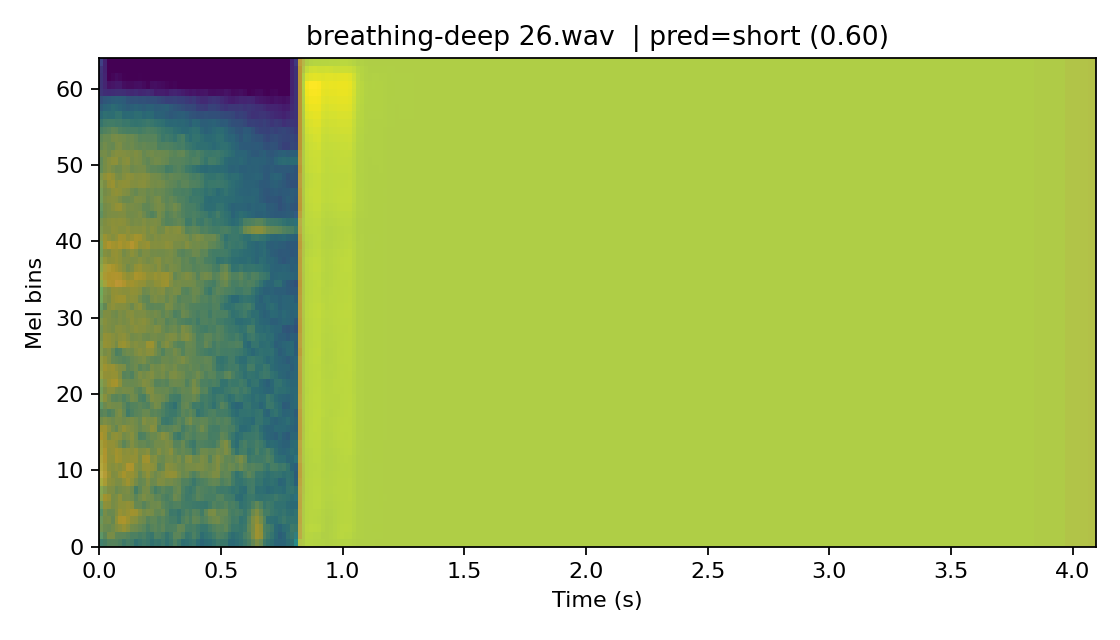

Long puff Grad-CAM (Figure 8.7):


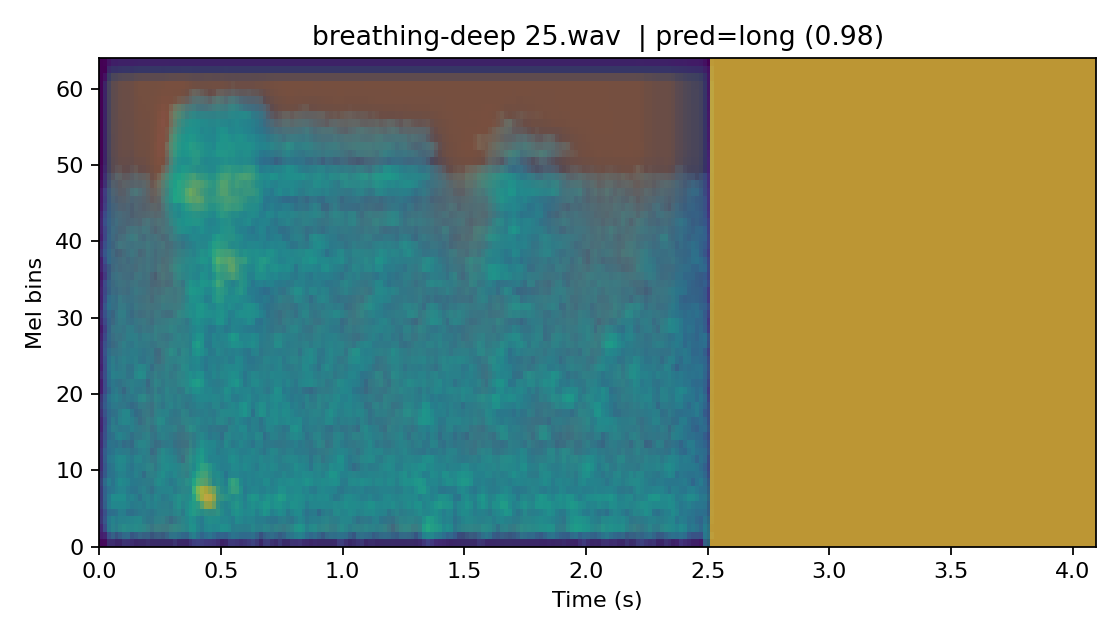

In [13]:
# CELL 7 — TC15/TC16 Grad-CAM
# Upload a real WAV from your laptop to Colab Files first
# Then update these paths:

SHORT_WAV = "data_segmets_test/0B1rE91KabdId1lUmWJB7NLg8OP2/short/breathing-shallow.wav"
LONG_WAV  = "data_segmets_test/0B1rE91KabdId1lUmWJB7NLg8OP2/long/breathing-deep.wav"

os.makedirs("viz/gradcam", exist_ok=True)

!python -m src.explain.gradcam_ms_tcn_2c \
  --wav {SHORT_WAV} \
  --ckpt models/ms_tcn_colab_1024.pt \
  --split_csv manifests/split_2c_subjectwise.csv \
  --out viz/gradcam/short_gradcam.png

!python -m src.explain.gradcam_ms_tcn_2c \
  --wav {LONG_WAV} \
  --ckpt models/ms_tcn_colab_1024.pt \
  --split_csv manifests/split_2c_subjectwise.csv \
  --out viz/gradcam/long_gradcam.png

from IPython.display import Image, display
print("Short puff Grad-CAM (Figure 8.6):")
display(Image("viz/gradcam/short_gradcam.png"))
print("Long puff Grad-CAM (Figure 8.7):")
display(Image("viz/gradcam/long_gradcam.png"))